In [1]:
!pip install -q fhir-aggregator-client lifelines

!fq --version

!fq

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires re

In [2]:
%env FHIR_BASE= https://google-fhir.fhir-aggregator.org/

env: FHIR_BASE=https://google-fhir.fhir-aggregator.org/


In [3]:
! rm -rf /root/.fhir-aggregator
!fq run cholangiocarcinoma-graph '/Condition?code:code=70179006'

Creating directory: /root/.fhir-aggregator
cholangiocarcinoma-graph is valid FHIR R5 GraphDefinition
ℹ Fetching https://google-fhir.fhir-aggregator.org/Condition?code:code=70179006
ℹ Processing Condition with 389 resources
ℹ Processing 1 links for Condition in parallel.
ℹ Processing link: Patient/_id={ref} with 354 Condition(s)
✔ Processed link: Patient/_id={ref}
ℹ Processing Patient with 389 resources
ℹ Processing 10 links for Patient in parallel.
ℹ Processing link: ResearchSubject/individual={ref}&_include=ResearchSubject:study with 354 Patient(s)
ℹ Processing link: Group/member={ref} with 354 Patient(s)
ℹ Processing link: Specimen/subject={ref} with 354 Patient(s)
ℹ Processing link: Observation/subject={ref}&code=NCIT_C156418,NCIT_C156419,NCIT_C164934&_count=1000&_total=accurate with 354 Patient(s)
ℹ Processing link: Procedure/subject={ref} with 354 Patient(s)
ℹ Processing link: DocumentReference/subject={ref}&_count=1000&_total=accurate with 354 Patient(s)
✖ Could not find any reso

In [4]:
!fq results visualize

Wrote: fhir-graph.html


In [5]:
from IPython.display import HTML
with open('fhir-graph.html', 'r') as file:
    html_content = file.read()
display(HTML("<div style='height: 800px;'>{}</div>".format(html_content)))

In [6]:
!fq results dataframe

Saved fhir-graph.tsv


In [7]:
import sqlite3
import pandas as pd

path = "/root/.fhir-aggregator/fhir-graph.sqlite"
conn = sqlite3.connect(path)

df_raw = pd.read_sql_query("SELECT * FROM resources", conn)

conn.close()
df_raw

,id,resource_type,key,resource
0,f1f5d536-ec6a-565b-9bb4-e7a459e47de3,Condition,Condition/f1f5d536-ec6a-565b-9bb4-e7a459e47de3,"{""category"": [{""coding"": [{""code"": ""encounter-..."
1,bcc646fb-6b16-50e6-bff0-9850431eb764,Condition,Condition/bcc646fb-6b16-50e6-bff0-9850431eb764,"{""category"": [{""coding"": [{""code"": ""encounter-..."
2,8fcb93f3-9687-5603-94fa-3dce12f747b8,Condition,Condition/8fcb93f3-9687-5603-94fa-3dce12f747b8,"{""category"": [{""coding"": [{""code"": ""encounter-..."
3,c1a0b7bb-13e1-5243-94e3-55f013df77de,Condition,Condition/c1a0b7bb-13e1-5243-94e3-55f013df77de,"{""category"": [{""coding"": [{""code"": ""encounter-..."
4,709b9fe4-373d-5620-b778-e4d5a633bc55,Condition,Condition/709b9fe4-373d-5620-b778-e4d5a633bc55,"{""category"": [{""coding"": [{""code"": ""encounter-..."
...,...,...,...,...
12403,e1bbe81e-0bb0-5be2-a2a5-8e76e6711908,Observation,Observation/e1bbe81e-0bb0-5be2-a2a5-8e76e6711908,"{""category"": [{""coding"": [{""code"": ""laboratory..."
12404,62a9eb5e-2708-5b10-a46b-f3c41936b301,Observation,Observation/62a9eb5e-2708-5b10-a46b-f3c41936b301,"{""category"": [{""coding"": [{""code"": ""laboratory..."
12405,fb85ef15-802e-5792-88ac-72d18952db19,Observation,Observation/fb85ef15-802e-5792-88ac-72d18952db19,"{""category"": [{""coding"": [{""code"": ""laboratory..."
12406,1d602694-91c9-5bac-b45a-28cbff3418f0,Observation,Observation/1d602694-91c9-5bac-b45a-28cbff3418f0,"{""category"": [{""coding"": [{""code"": ""laboratory..."


In [8]:
import orjson

research_studies = df_raw[df_raw.resource_type.isin(["ResearchStudy"])]

titles = [orjson.loads(resource)['title'] for resource in research_studies.resource]
print(titles)

['tcga_lihc', 'FM-AD', 'MATCH-W', 'MATCH-Z1D', 'tcga_chol', 'MATCH-Z1A', 'MATCH-B', 'MATCH-C1', 'MATCH-S1', 'MATCH-H', 'MATCH-U', 'MATCH-Q', 'EXCEPTIONAL_RESPONDERS-ER', 'MATCH-I', 'MATCH-P', 'tcga_uvm', 'phs002431', 'HCMI-CMDC']


extracting datasets for summary plots...
final dataset: 411 patients


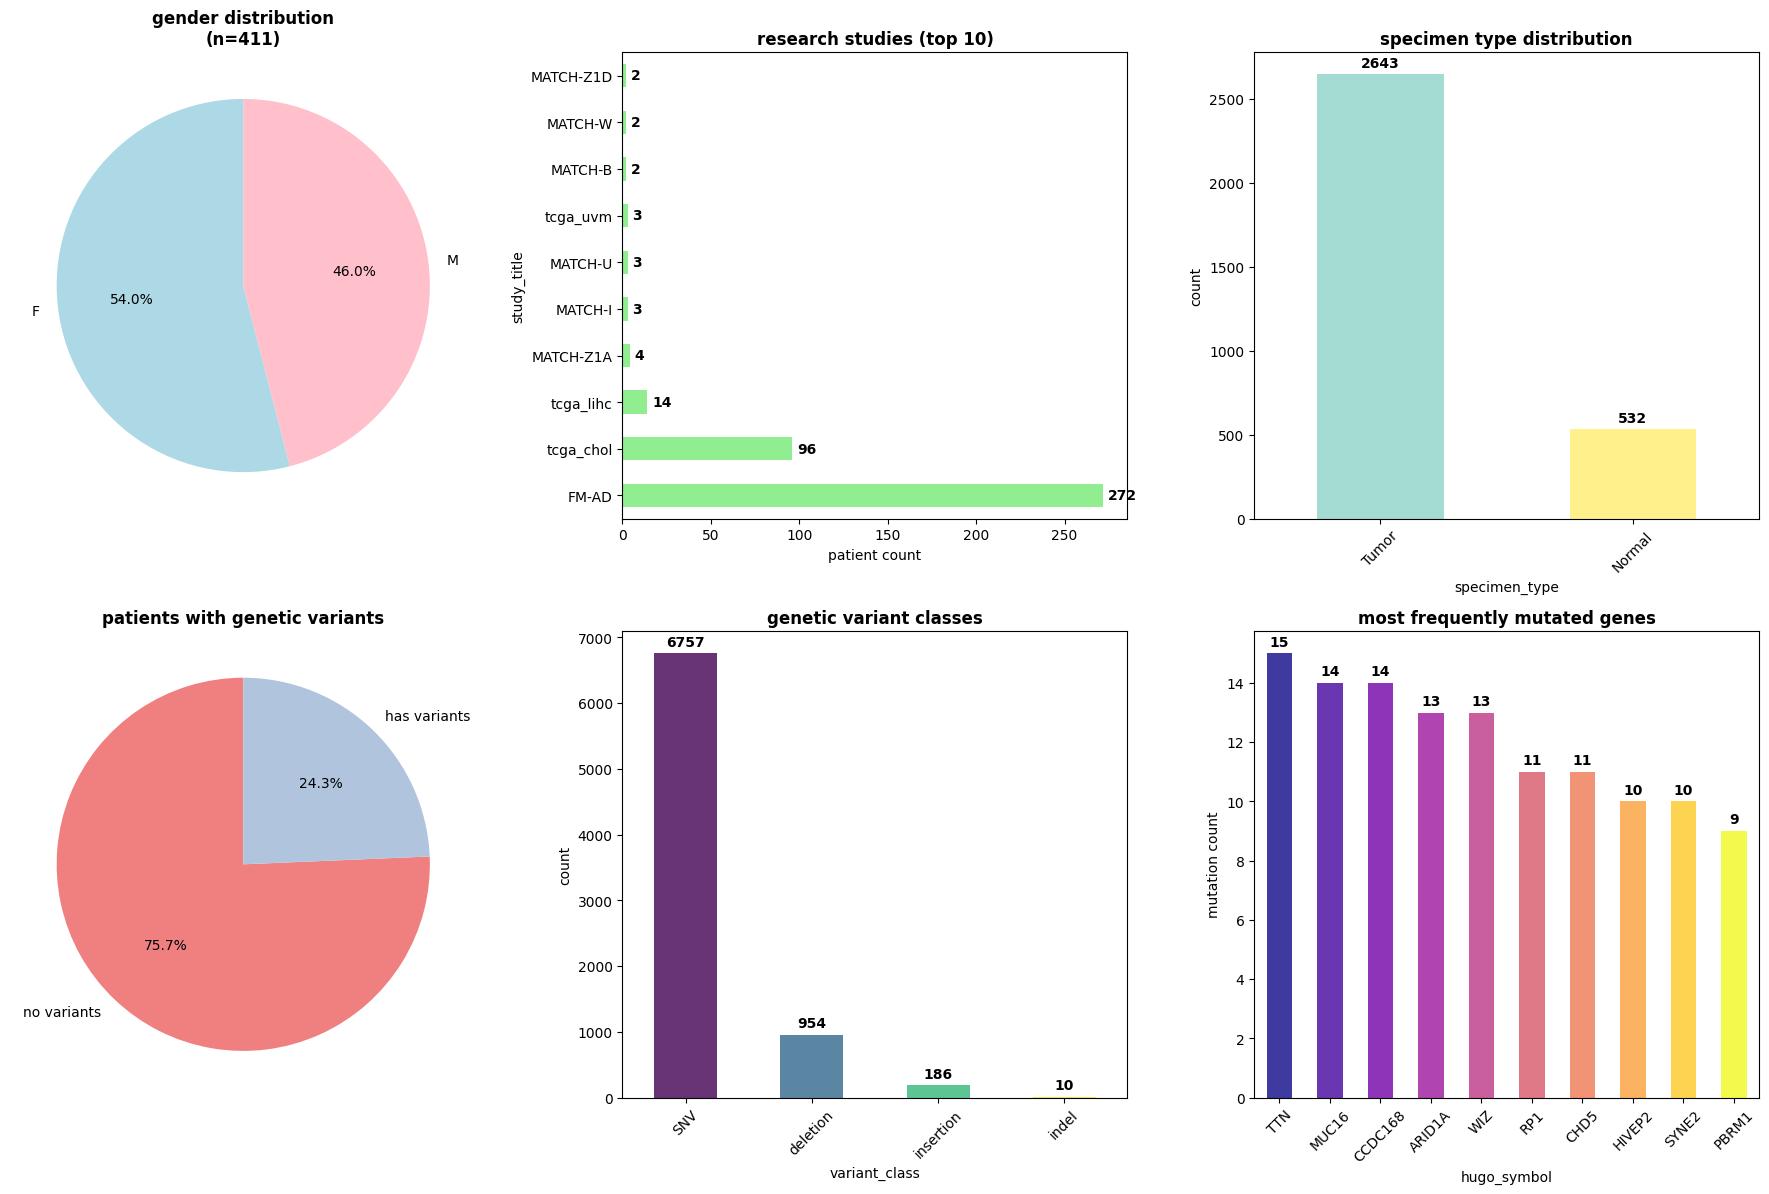


dataset summary:
patients: 354
specimens: 3175 (354 patients)
genetic variants: 7907 (50 patients)
research studies: 18
patient-study assignments: 411
gender: {'F': 191, 'M': 163}
specimen types: {'Tumor': 2643, 'Normal': 532}
variant classes: {'SNV': 6757, 'deletion': 954, 'insertion': 186, 'indel': 10}


In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

# create resource_dfs from df_raw
resource_dfs = {}
for resource_type in df_raw['resource_type'].unique():
    resource_dfs[resource_type] = df_raw[df_raw['resource_type'] == resource_type].copy()

# extract and create clean datasets
print("extracting datasets for summary plots...")

# 1. patient demographics
patients = []
df_patient = resource_dfs['Patient']
for i, row in df_patient.iterrows():
    try:
        patient_json = json.loads(row['resource'])
        patient_data = {'patient_id': patient_json.get('id')}

        if 'extension' in patient_json:
            for ext in patient_json['extension']:
                if 'url' in ext:
                    if 'us-core-birthsex' in ext['url']:
                        patient_data['gender'] = ext.get('valueCode')
                    elif 'us-core-race' in ext['url']:
                        patient_data['race'] = ext.get('valueCode', ext.get('valueString'))
                    elif 'us-core-ethnicity' in ext['url']:
                        patient_data['ethnicity'] = ext.get('valueCode', ext.get('valueString'))
        patients.append(patient_data)
    except:
        continue
df_patients = pd.DataFrame(patients)

# 2. research studies and patient assignments
studies = []
df_research_study = resource_dfs['ResearchStudy']
for i, row in df_research_study.iterrows():
    try:
        study_json = json.loads(row['resource'])
        studies.append({
            'study_id': study_json.get('id'),
            'study_title': study_json.get('title', 'unknown'),
            'study_status': study_json.get('status', 'unknown')
        })
    except:
        continue
df_studies = pd.DataFrame(studies)

patient_studies = []
df_research_subject = resource_dfs['ResearchSubject']
for i, row in df_research_subject.iterrows():
    try:
        subject_json = json.loads(row['resource'])
        if ('individual' in subject_json and 'reference' in subject_json['individual'] and
            'study' in subject_json and 'reference' in subject_json['study']):
            patient_studies.append({
                'patient_id': subject_json['individual']['reference'].replace('Patient/', ''),
                'study_id': subject_json['study']['reference'].replace('ResearchStudy/', '')
            })
    except:
        continue
df_patient_studies = pd.DataFrame(patient_studies)

# 3. specimens
specimens = []
df_specimen = resource_dfs['Specimen']
for i, row in df_specimen.iterrows():
    try:
        specimen_json = json.loads(row['resource'])
        specimen_data = {
            'specimen_id': specimen_json.get('id'),
            'specimen_type': 'unknown'
        }

        if 'type' in specimen_json and 'coding' in specimen_json['type']:
            if len(specimen_json['type']['coding']) > 0:
                specimen_data['specimen_type'] = specimen_json['type']['coding'][0].get('display', 'unknown')

        if 'subject' in specimen_json and 'reference' in specimen_json['subject']:
            specimen_data['patient_id'] = specimen_json['subject']['reference'].replace('Patient/', '')

        specimens.append(specimen_data)
    except:
        continue
df_specimens = pd.DataFrame(specimens)

# 4. genetic variants
variants = []
df_obs = resource_dfs['Observation']
for i, row in df_obs.iterrows():
    try:
        obs_json = json.loads(row['resource'])

        patient_id = None
        if 'subject' in obs_json and 'reference' in obs_json['subject']:
            patient_id = obs_json['subject']['reference'].replace('Patient/', '')

        if patient_id:
            obs_type = None
            if 'code' in obs_json and 'coding' in obs_json['code']:
                if len(obs_json['code']['coding']) > 0:
                    obs_type = obs_json['code']['coding'][0].get('display')

            if obs_type == 'Performed Genetic Observation Result Mutation Type Code':
                variant_data = {
                    'patient_id': patient_id,
                    'variant_class': None,
                    'hugo_symbol': None,
                    'project': None
                }

                if 'component' in obs_json:
                    for comp in obs_json['component']:
                        if 'code' in comp and 'valueString' in comp:
                            comp_code = None
                            if 'coding' in comp['code'] and len(comp['code']['coding']) > 0:
                                comp_code = comp['code']['coding'][0].get('display')

                            comp_value = comp['valueString']

                            if comp_code == 'variant_class':
                                variant_data['variant_class'] = comp_value
                            elif comp_code == 'hugo_symbol':
                                variant_data['hugo_symbol'] = comp_value
                            elif comp_code == 'project_short_name':
                                variant_data['project'] = comp_value

                variants.append(variant_data)
    except:
        continue
df_variants = pd.DataFrame(variants)

# merge key datasets
df_main = df_patient_studies.merge(df_patients, on='patient_id', how='left')
df_main = df_main.merge(df_studies, on='study_id', how='left')

# add specimen counts
specimen_summary = df_specimens.groupby(['patient_id', 'specimen_type']).size().unstack(fill_value=0)
if 'Normal' in specimen_summary.columns:
    specimen_summary['normal_specimens'] = specimen_summary['Normal']
if 'Tumor' in specimen_summary.columns:
    specimen_summary['tumor_specimens'] = specimen_summary['Tumor']
specimen_summary['total_specimens'] = specimen_summary.sum(axis=1)
df_main = df_main.merge(specimen_summary[['normal_specimens', 'tumor_specimens', 'total_specimens']],
                       on='patient_id', how='left')
df_main[['normal_specimens', 'tumor_specimens', 'total_specimens']] = df_main[['normal_specimens', 'tumor_specimens', 'total_specimens']].fillna(0)

# add variant counts
variant_summary = df_variants.groupby('patient_id').size().reset_index(name='total_variants')
df_main = df_main.merge(variant_summary, on='patient_id', how='left')
df_main['total_variants'] = df_main['total_variants'].fillna(0)

print(f"final dataset: {len(df_main)} patients")

# create summary plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# plot 1: gender distribution
if 'gender' in df_main.columns and df_main['gender'].notna().any():
    gender_counts = df_main['gender'].value_counts()
    colors = ['lightblue', 'pink'][:len(gender_counts)]
    gender_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title(f'gender distribution\n(n={gender_counts.sum()})', fontweight='bold')
    axes[0].set_ylabel('')
else:
    axes[0].text(0.5, 0.5, 'no gender data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('gender distribution')

# plot 2: research studies
if 'study_title' in df_main.columns and df_main['study_title'].notna().any():
    study_counts = df_main['study_title'].value_counts().head(10)
    study_counts.plot(kind='barh', ax=axes[1], color='lightgreen')
    axes[1].set_title('research studies (top 10)', fontweight='bold')
    axes[1].set_xlabel('patient count')
    for i, v in enumerate(study_counts.values):
        axes[1].text(v + max(study_counts.values) * 0.01, i, str(v), va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'no study data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('research studies')

# plot 3: specimen types
specimen_data = df_specimens['specimen_type'].value_counts()
if not specimen_data.empty:
    colors = plt.cm.Set3(np.linspace(0, 1, len(specimen_data)))
    specimen_data.plot(kind='bar', ax=axes[2], color=colors, alpha=0.8)
    axes[2].set_title('specimen type distribution', fontweight='bold')
    axes[2].set_ylabel('count')
    axes[2].tick_params(axis='x', rotation=45)
    for i, v in enumerate(specimen_data.values):
        axes[2].text(i, v + max(specimen_data.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'no specimen data', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('specimen types')

# plot 4: patients with genetic data
if 'total_variants' in df_main.columns:
    genetic_status = (df_main['total_variants'] > 0).value_counts()
    genetic_status.index = ['no variants', 'has variants']
    genetic_status.plot(kind='pie', ax=axes[3], autopct='%1.1f%%',
                       colors=['lightcoral', 'lightsteelblue'], startangle=90)
    axes[3].set_title('patients with genetic variants', fontweight='bold')
    axes[3].set_ylabel('')
else:
    axes[3].text(0.5, 0.5, 'no variant data', ha='center', va='center', transform=axes[3].transAxes)
    axes[3].set_title('genetic variants')

# plot 5: variant classes
if not df_variants.empty and 'variant_class' in df_variants.columns:
    variant_classes = df_variants['variant_class'].value_counts().head(8)
    colors = plt.cm.viridis(np.linspace(0, 1, len(variant_classes)))
    variant_classes.plot(kind='bar', ax=axes[4], color=colors, alpha=0.8)
    axes[4].set_title('genetic variant classes', fontweight='bold')
    axes[4].set_ylabel('count')
    axes[4].tick_params(axis='x', rotation=45)
    for i, v in enumerate(variant_classes.values):
        axes[4].text(i, v + max(variant_classes.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[4].text(0.5, 0.5, 'no variant classes', ha='center', va='center', transform=axes[4].transAxes)
    axes[4].set_title('variant classes')

# plot 6: top mutated genes
if not df_variants.empty and 'hugo_symbol' in df_variants.columns and df_variants['hugo_symbol'].notna().any():
    top_genes = df_variants['hugo_symbol'].value_counts().head(10)
    colors = plt.cm.plasma(np.linspace(0, 1, len(top_genes)))
    top_genes.plot(kind='bar', ax=axes[5], color=colors, alpha=0.8)
    axes[5].set_title('most frequently mutated genes', fontweight='bold')
    axes[5].set_ylabel('mutation count')
    axes[5].tick_params(axis='x', rotation=45)
    for i, v in enumerate(top_genes.values):
        axes[5].text(i, v + max(top_genes.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[5].text(0.5, 0.5, 'no gene symbols\navailable', ha='center', va='center', transform=axes[5].transAxes)
    axes[5].set_title('mutated genes')

plt.tight_layout()
plt.show()

# print summary statistics
print(f"\ndataset summary:")
print(f"patients: {len(df_patients)}")
print(f"specimens: {len(df_specimens)} ({df_specimens['patient_id'].nunique()} patients)")
print(f"genetic variants: {len(df_variants)} ({df_variants['patient_id'].nunique()} patients)")
print(f"research studies: {len(df_studies)}")
print(f"patient-study assignments: {len(df_patient_studies)}")

if 'gender' in df_patients.columns:
    print(f"gender: {df_patients['gender'].value_counts().to_dict()}")

if not df_specimens.empty:
    print(f"specimen types: {df_specimens['specimen_type'].value_counts().to_dict()}")

if not df_variants.empty and 'variant_class' in df_variants.columns:
    print(f"variant classes: {df_variants['variant_class'].value_counts().to_dict()}")

extracting temporal data for kaplan-meier analysis...
extracted 69 temporal observations
found 20 diagnosis-to-death observations
survival analysis dataset: 41 patients
mean survival: 1.8 years
median survival: 1.5 years

debugging variant class data:
survival patients: 41
variant classes in all data: {'SNV': 6757, 'deletion': 954, 'insertion': 186, 'indel': 10}
variant classes in survival cohort: {'SNV': 2888, 'deletion': 142, 'insertion': 40, 'indel': 6}
mutation categories in survival cohort: {'SNV': 2888, 'indel/deletion': 188}


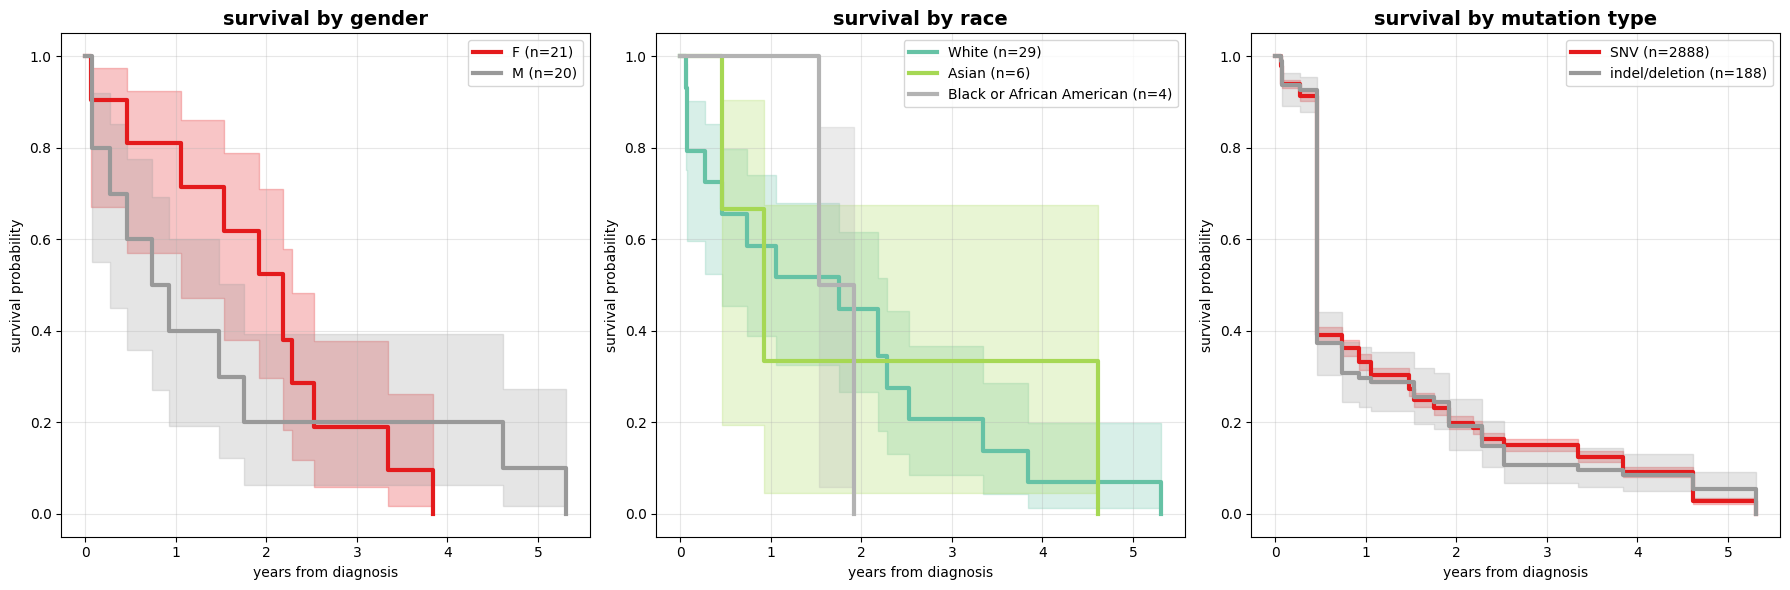


comprehensive survival analysis:
patients analyzed: 41
overall median survival: 1.54 years

survival by all genders:
  M: n=20, median=0.84 years
  F: n=21, median=2.18 years

survival by all races:
  Asian: n=6, median=0.93 years
  White: n=29, median=1.75 years
  Black or African American: n=4, median=1.73 years

survival by mutation categories:
  SNV: n=2888, median=0.47 years
  indel/deletion: n=188, median=0.47 years


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

kmf = KaplanMeierFitter()

plt.style.use('default')
sns.set_palette("husl")

print("extracting temporal data for kaplan-meier analysis...")

# extract temporal observations
temporal_data = []
df_obs = resource_dfs['Observation']

for i, row in df_obs.iterrows():
    try:
        obs_json = json.loads(row['resource'])

        patient_id = None
        if 'subject' in obs_json and 'reference' in obs_json['subject']:
            patient_id = obs_json['subject']['reference'].replace('Patient/', '')

        if patient_id:
            obs_type = None
            if 'code' in obs_json and 'coding' in obs_json['code']:
                if len(obs_json['code']['coding']) > 0:
                    obs_type = obs_json['code']['coding'][0].get('display')

            # extract temporal values
            if obs_type in ['Days between Diagnosis and Death', 'Days Between Birth and Diagnosis']:
                if 'valueQuantity' in obs_json and 'value' in obs_json['valueQuantity']:
                    temporal_data.append({
                        'patient_id': patient_id,
                        'obs_type': obs_type,
                        'days': obs_json['valueQuantity']['value']
                    })
    except:
        continue

df_temporal = pd.DataFrame(temporal_data)
print(f"extracted {len(df_temporal)} temporal observations")

# prepare survival data
survival_data = []
diagnosis_death = df_temporal[df_temporal['obs_type'] == 'Days between Diagnosis and Death']

if not diagnosis_death.empty:
    print(f"found {len(diagnosis_death)} diagnosis-to-death observations")

    # merge with patient data to get demographics and study info
    df_survival_base = df_main.merge(diagnosis_death[['patient_id', 'days']], on='patient_id', how='inner')
    df_survival_base = df_survival_base.rename(columns={'days': 'survival_days'})
    df_survival_base['survival_years'] = df_survival_base['survival_days'] / 365.25

    # create event indicator (1 = death observed, 0 = censored)
    # since we have "days to death", these are all death events
    df_survival_base['event'] = 1

    print(f"survival analysis dataset: {len(df_survival_base)} patients")
    print(f"mean survival: {df_survival_base['survival_years'].mean():.1f} years")
    print(f"median survival: {df_survival_base['survival_years'].median():.1f} years")

    # create kaplan-meier plots - show all groups
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # plot 1: survival by gender (all genders)
    ax = axes[0]
    if 'gender' in df_survival_base.columns and df_survival_base['gender'].notna().sum() > 0:
        gender_groups = df_survival_base['gender'].value_counts()
        colors = plt.cm.Set1(np.linspace(0, 1, len(gender_groups)))

        for i, (gender, color) in enumerate(zip(gender_groups.index, colors)):
            if gender_groups[gender] >= 1:  # show all groups with at least 1 patient
                gender_data = df_survival_base[df_survival_base['gender'] == gender]
                kmf.fit(gender_data['survival_years'], gender_data['event'],
                       label=f'{gender} (n={len(gender_data)})')
                kmf.plot_survival_function(ax=ax, color=color, linewidth=3)

        ax.set_title('survival by gender', fontweight='bold', fontsize=14)
        ax.set_xlabel('years from diagnosis')
        ax.set_ylabel('survival probability')
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'no gender data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('survival by gender')

    # plot 2: survival by race (all races)
    ax = axes[1]
    if 'race' in df_survival_base.columns and df_survival_base['race'].notna().sum() > 0:
        race_groups = df_survival_base['race'].value_counts()
        colors = plt.cm.Set2(np.linspace(0, 1, len(race_groups)))

        for i, (race, color) in enumerate(zip(race_groups.index, colors)):
            if race_groups[race] >= 1:  # show all races with at least 1 patient
                race_data = df_survival_base[df_survival_base['race'] == race]
                kmf.fit(race_data['survival_years'], race_data['event'],
                       label=f'{race} (n={len(race_data)})')
                kmf.plot_survival_function(ax=ax, color=color, linewidth=3)

        ax.set_title('survival by race', fontweight='bold', fontsize=14)
        ax.set_xlabel('years from diagnosis')
        ax.set_ylabel('survival probability')
        ax.grid(True, alpha=0.3)
        ax.legend()

    elif 'ethnicity' in df_survival_base.columns and df_survival_base['ethnicity'].notna().sum() > 0:
        # fallback to ethnicity if no race data
        eth_groups = df_survival_base['ethnicity'].value_counts()
        colors = plt.cm.Set2(np.linspace(0, 1, len(eth_groups)))

        for i, (ethnicity, color) in enumerate(zip(eth_groups.index, colors)):
            if eth_groups[ethnicity] >= 1:
                eth_data = df_survival_base[df_survival_base['ethnicity'] == ethnicity]
                kmf.fit(eth_data['survival_years'], eth_data['event'],
                       label=f'{ethnicity} (n={len(eth_data)})')
                kmf.plot_survival_function(ax=ax, color=color, linewidth=3)

        ax.set_title('survival by ethnicity', fontweight='bold', fontsize=14)
        ax.set_xlabel('years from diagnosis')
        ax.set_ylabel('survival probability')
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'no race/ethnicity data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('survival by race')

    # plot 3: survival by variant class (SNV vs deletion vs others)
    ax = axes[2]

    # merge with variant data to get variant classes
    df_survival_variants = df_survival_base.merge(
        df_variants[df_variants['variant_class'].notna()][['patient_id', 'variant_class']],
        on='patient_id', how='left'
    )

    # debug variant class distribution
    print(f"\ndebugging variant class data:")
    print(f"survival patients: {len(df_survival_base)}")

    if not df_variants.empty and 'variant_class' in df_variants.columns:
        variant_class_counts = df_variants['variant_class'].value_counts()
        print(f"variant classes in all data: {variant_class_counts.to_dict()}")

        # check how many survival patients have each variant class
        survival_variant_counts = df_survival_variants['variant_class'].value_counts()
        print(f"variant classes in survival cohort: {survival_variant_counts.to_dict()}")

        # create broader groups for better sample sizes
        def categorize_variant(variant_class):
            if pd.isna(variant_class):
                return 'no mutations'
            elif variant_class == 'SNV':
                return 'SNV'
            elif variant_class in ['deletion', 'insertion', 'indel']:
                return 'indel/deletion'
            else:
                return 'other mutations'

        df_survival_variants['mutation_category'] = df_survival_variants['variant_class'].apply(categorize_variant)

        mutation_groups = df_survival_variants['mutation_category'].value_counts()
        print(f"mutation categories in survival cohort: {mutation_groups.to_dict()}")

        # plot survival curves for each category with sufficient patients
        colors = plt.cm.Set1(np.linspace(0, 1, len(mutation_groups)))
        plotted_groups = 0

        for i, (category, color) in enumerate(zip(mutation_groups.index, colors)):
            if mutation_groups[category] >= 1:  # show all groups
                cat_data = df_survival_variants[df_survival_variants['mutation_category'] == category]
                kmf.fit(cat_data['survival_years'], cat_data['event'],
                       label=f'{category} (n={len(cat_data)})')
                kmf.plot_survival_function(ax=ax, color=color, linewidth=3)
                plotted_groups += 1

        if plotted_groups > 0:
            ax.set_title('survival by mutation type', fontweight='bold', fontsize=14)
            ax.set_xlabel('years from diagnosis')
            ax.set_ylabel('survival probability')
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'insufficient mutation data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('survival by mutation type')
    else:
        ax.text(0.5, 0.5, 'no variant class data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('survival by mutation type')

    plt.tight_layout()
    plt.show()

    # comprehensive summary statistics
    print(f"\ncomprehensive survival analysis:")
    print(f"patients analyzed: {len(df_survival_base)}")
    print(f"overall median survival: {df_survival_base['survival_years'].median():.2f} years")

    if 'gender' in df_survival_base.columns and df_survival_base['gender'].notna().sum() > 0:
        print(f"\nsurvival by all genders:")
        for gender in df_survival_base['gender'].dropna().unique():
            gender_data = df_survival_base[df_survival_base['gender'] == gender]
            print(f"  {gender}: n={len(gender_data)}, median={gender_data['survival_years'].median():.2f} years")

    # show all races
    if 'race' in df_survival_base.columns and df_survival_base['race'].notna().sum() > 0:
        print(f"\nsurvival by all races:")
        for race in df_survival_base['race'].dropna().unique():
            race_data = df_survival_base[df_survival_base['race'] == race]
            print(f"  {race}: n={len(race_data)}, median={race_data['survival_years'].median():.2f} years")
    elif 'ethnicity' in df_survival_base.columns and df_survival_base['ethnicity'].notna().sum() > 0:
        print(f"\nsurvival by all ethnicities:")
        for ethnicity in df_survival_base['ethnicity'].dropna().unique():
            eth_data = df_survival_base[df_survival_base['ethnicity'] == ethnicity]
            print(f"  {ethnicity}: n={len(eth_data)}, median={eth_data['survival_years'].median():.2f} years")

    # show mutation data
    if not df_variants.empty and 'variant_class' in df_variants.columns:
        print(f"\nsurvival by mutation categories:")
        for category in df_survival_variants['mutation_category'].dropna().unique():
            cat_data = df_survival_variants[df_survival_variants['mutation_category'] == category]
            if len(cat_data) > 0:
                print(f"  {category}: n={len(cat_data)}, median={cat_data['survival_years'].median():.2f} years")

else:
    print("no diagnosis-to-death temporal data found for survival analysis")
    print("available temporal observations:")
    if not df_temporal.empty:
        print(df_temporal['obs_type'].value_counts())

# alternative: specimen collection timeline analysis if no survival data
if diagnosis_death.empty and not df_specimens.empty:
    print("\nusing specimen collection as timeline proxy...")

    # this would be specimen collection timing, not survival
    birth_diagnosis = df_temporal[df_temporal['obs_type'] == 'Days Between Birth and Diagnosis']

    if not birth_diagnosis.empty:
        df_timeline = df_main.merge(birth_diagnosis[['patient_id', 'days']], on='patient_id', how='inner')
        df_timeline['age_at_diagnosis'] = df_timeline['days'] / 365.25

        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.hist(df_timeline['age_at_diagnosis'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title('age at diagnosis distribution')
        plt.xlabel('age (years)')
        plt.ylabel('frequency')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        if 'gender' in df_timeline.columns and df_timeline['gender'].notna().sum() > 5:
            for gender in df_timeline['gender'].dropna().unique():
                gender_data = df_timeline[df_timeline['gender'] == gender]
                plt.hist(gender_data['age_at_diagnosis'], alpha=0.6,
                        label=f'{gender} (n={len(gender_data)})', bins=15)
            plt.title('age at diagnosis by gender')
            plt.xlabel('age (years)')
            plt.ylabel('frequency')
            plt.legend()
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"\nage at diagnosis summary:")
        print(f"patients: {len(df_timeline)}")
        print(f"mean age: {df_timeline['age_at_diagnosis'].mean():.1f} years")
        print(f"median age: {df_timeline['age_at_diagnosis'].median():.1f} years")
        print(f"age range: {df_timeline['age_at_diagnosis'].min():.1f} - {df_timeline['age_at_diagnosis'].max():.1f} years")

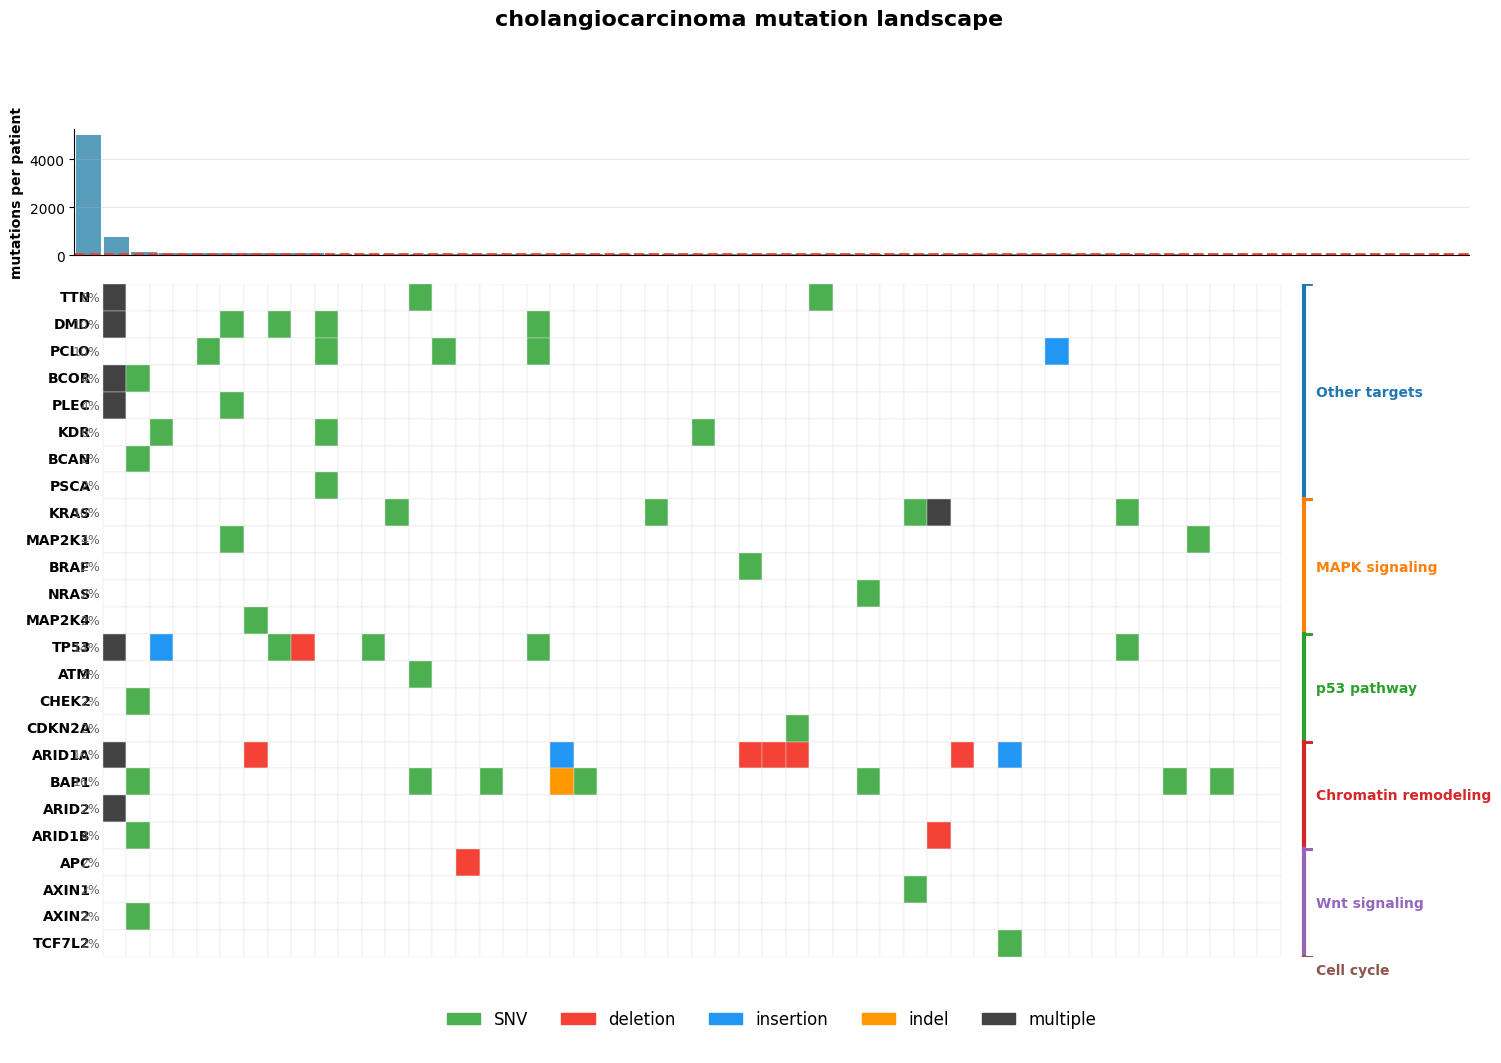

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec
import seaborn as sns
from scipy.stats import fisher_exact
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# hardcoded pathway definitions for cholangiocarcinoma
CHOLANGIOCARCINOMA_PATHWAYS = {
    "MAPK signaling": ["KRAS", "BRAF", "NRAS", "MAP2K1", "MAP2K4", "MAPK1", "MAPK3"],
    "PI3K/AKT pathway": ["PIK3CA", "PTEN", "AKT1", "MTOR", "PIK3R1"],
    "p53 pathway": ["TP53", "ATM", "CHEK2", "MDM2", "CDKN1A", "CDKN2A"],
    "Chromatin remodeling": ["ARID1A", "ARID1B", "BAP1", "SMARCA4", "SMARCB1", "ARID2"],
    "DNA repair": ["BRCA1", "BRCA2", "ATR", "PALB2", "BRIP1", "RAD51C"],
    "Cell cycle": ["CDKN2A", "CCND1", "RB1", "E2F1", "CDK4", "CDK6"],
    "Wnt signaling": ["APC", "CTNNB1", "AXIN1", "GSK3B", "AXIN2", "TCF7L2"],
    "Metabolism": ["IDH1", "IDH2", "MSMO1", "TYMP"],
    "Other targets": ["PCLO", "PLEC", "KDR", "DMD", "BCAN", "BCOR", "PSCA", "TTN"]
}

MUTATION_COLORS = {
    "SNV": "#4CAF50",
    "deletion": "#F44336",
    "insertion": "#2196F3",
    "indel": "#FF9800",
    "multiple": "#424242"
}

def pathway_enrichment_analysis(mutated_genes):
    """perform fisher exact test for pathway enrichment"""
    enriched_pathways = []

    for pathway_name, pathway_genes in CHOLANGIOCARCINOMA_PATHWAYS.items():
        mutated_in_pathway = len(set(mutated_genes).intersection(set(pathway_genes)))
        if mutated_in_pathway > 0:
            enriched_pathways.append({
                'pathway': pathway_name,
                'mutated_genes': mutated_in_pathway,
                'total_genes': len(pathway_genes),
                'genes': [g for g in pathway_genes if g in mutated_genes]
            })

    return sorted(enriched_pathways, key=lambda x: x['mutated_genes'], reverse=True)

def get_pathway_ordered_genes(df_mutations):
    """order genes by pathway groups and mutation frequency"""
    # get all mutated genes
    gene_counts = df_mutations['gene'].value_counts()
    mutated_genes = gene_counts.index.tolist()

    # perform enrichment
    enriched_pathways = pathway_enrichment_analysis(mutated_genes)

    # organize genes by pathway
    ordered_genes = []
    used_genes = set()

    # add genes from enriched pathways in order
    for pathway_info in enriched_pathways:
        pathway_genes = pathway_info['genes']
        # sort by frequency within pathway
        pathway_genes_sorted = sorted(pathway_genes,
                                    key=lambda g: gene_counts.get(g, 0), reverse=True)
        for gene in pathway_genes_sorted:
            if gene not in used_genes:
                ordered_genes.append(gene)
                used_genes.add(gene)

    # add remaining genes not in pathways
    for gene in mutated_genes:
        if gene not in used_genes:
            ordered_genes.append(gene)

    return ordered_genes[:25], enriched_pathways  # limit to top 25 genes

def create_waterfall_oncoprint(df_variants):
    """create waterfall-style oncoprint"""

    # extract mutations
    mutations = []
    for _, row in df_variants.iterrows():
        if pd.notna(row.get('hugo_symbol')) and pd.notna(row.get('patient_id')):
            mutations.append({
                'patient_id': row['patient_id'],
                'gene': row['hugo_symbol'],
                'variant_class': row.get('variant_class', 'SNV')
            })

    df_mutations = pd.DataFrame(mutations)
    if df_mutations.empty:
        return None

    # get ordered genes and pathways
    ordered_genes, pathway_info = get_pathway_ordered_genes(df_mutations)

    # order patients by total mutation count (waterfall effect)
    patient_mutation_counts = df_mutations.groupby('patient_id').size().sort_values(ascending=False)
    ordered_patients = patient_mutation_counts.head(50).index.tolist()  # top 50 patients

    # create figure with proper layout
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 1, height_ratios=[1.5, 8, 0.8], hspace=0.1)

    # mutation burden barplot (top)
    ax_burden = fig.add_subplot(gs[0, 0])
    burden_values = [patient_mutation_counts.get(p, 0) for p in ordered_patients]

    bars = ax_burden.bar(range(len(ordered_patients)), burden_values,
                        color='#2E86AB', alpha=0.8, width=0.9)

    # add median line
    median_val = np.median(burden_values)
    ax_burden.axhline(y=median_val, color='#F24236', linestyle='--', linewidth=2)

    ax_burden.set_xlim(-0.5, len(ordered_patients) - 0.5)
    ax_burden.set_ylabel('mutations per patient', fontweight='bold')
    ax_burden.set_xticks([])
    ax_burden.spines['top'].set_visible(False)
    ax_burden.spines['right'].set_visible(False)
    ax_burden.grid(axis='y', alpha=0.3)

    # main oncoprint grid (center)
    ax_onco = fig.add_subplot(gs[1, 0])

    # create mutation lookup
    mutation_dict = {}
    for _, row in df_mutations.iterrows():
        key = (row['gene'], row['patient_id'])
        if key not in mutation_dict:
            mutation_dict[key] = []
        mutation_dict[key].append(row['variant_class'])

    # plot mutation grid
    for i, gene in enumerate(ordered_genes):
        y_pos = len(ordered_genes) - i - 1

        for j, patient in enumerate(ordered_patients):
            rect = patches.Rectangle(
                (j, y_pos), 1, 1,
                linewidth=0.3, edgecolor='#E0E0E0',
                facecolor='white'
            )
            ax_onco.add_patch(rect)

            key = (gene, patient)
            if key in mutation_dict:
                mutations_list = mutation_dict[key]
                if len(mutations_list) == 1:
                    color = MUTATION_COLORS.get(mutations_list[0], '#666666')
                else:
                    color = MUTATION_COLORS['multiple']
                rect.set_facecolor(color)

    # add gene labels with frequencies
    for i, gene in enumerate(ordered_genes):
        y_pos = len(ordered_genes) - i - 1 + 0.5

        # gene name
        ax_onco.text(-0.5, y_pos, gene, ha='right', va='center',
                    fontweight='bold', fontsize=10)

        # frequency
        gene_patients = set(df_mutations[df_mutations['gene'] == gene]['patient_id'])
        freq = (len(gene_patients.intersection(set(ordered_patients))) / len(ordered_patients)) * 100
        ax_onco.text(-0.1, y_pos, f'{freq:.0f}%', ha='right', va='center',
                    fontsize=9, color='#666666')

    # add pathway groupings on the right
    y_position = len(ordered_genes)
    pathway_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                     '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']
    color_idx = 0

    for pathway_data in pathway_info:
        pathway_name = pathway_data['pathway']
        pathway_genes = [g for g in pathway_data['genes'] if g in ordered_genes]

        if pathway_genes:
            n_genes = len(pathway_genes)
            y_position -= n_genes

            # draw bracket
            bracket_x = len(ordered_patients) + 1
            bracket_color = pathway_colors[color_idx % len(pathway_colors)]

            # vertical line
            ax_onco.plot([bracket_x, bracket_x], [y_position, y_position + n_genes],
                        color=bracket_color, linewidth=3)

            # top and bottom horizontals
            ax_onco.plot([bracket_x, bracket_x + 0.3], [y_position, y_position],
                        color=bracket_color, linewidth=2)
            ax_onco.plot([bracket_x, bracket_x + 0.3], [y_position + n_genes, y_position + n_genes],
                        color=bracket_color, linewidth=2)

            # pathway label
            ax_onco.text(bracket_x + 0.5, y_position + n_genes/2, pathway_name,
                        va='center', ha='left', fontsize=10, fontweight='bold',
                        color=bracket_color, rotation=0)

            color_idx += 1

    ax_onco.set_xlim(-1.2, len(ordered_patients) + 8)
    ax_onco.set_ylim(0, len(ordered_genes))
    ax_onco.set_xticks([])
    ax_onco.set_yticks([])

    # remove all spines
    for spine in ax_onco.spines.values():
        spine.set_visible(False)

    # legend (bottom)
    ax_legend = fig.add_subplot(gs[2, 0])
    legend_elements = []

    # only show mutation types that exist in the data
    existing_types = set()
    for mutations_list in mutation_dict.values():
        existing_types.update(mutations_list)

    for variant_type in ['SNV', 'deletion', 'insertion', 'indel', 'multiple']:
        if variant_type in existing_types or variant_type == 'multiple':
            color = MUTATION_COLORS[variant_type]
            legend_elements.append(patches.Patch(color=color, label=variant_type))

    ax_legend.legend(handles=legend_elements, loc='center', ncol=len(legend_elements),
                    frameon=False, fontsize=12)
    ax_legend.axis('off')

    plt.suptitle('cholangiocarcinoma mutation landscape',
                fontsize=16, fontweight='bold', y=0.98)

    return fig

# create the waterfall oncoprint
if 'df_variants' in globals() and not df_variants.empty:
    fig = create_waterfall_oncoprint(df_variants)
    if fig:
        plt.tight_layout()
        plt.show()